In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import sys

sys.path.insert(0, "../preprocessing")
from feature_pipeline import build_feature_table

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RAW_FILES = [
    "../dataset/raw/EXP_01_NORMAL_STATIONARY.csv",
    "../dataset/raw/EXP_02_PHYSICAL_EXPERIMENTS_LABELED.csv",
]
PROCESSED_PATH = "../dataset/processed/physical_motion_features.csv"

MOTION_FEATURES = [
    "accel_mag", "gyro_mag", "delta_accel", "delta_gyro",
    "rolling_mean", "rolling_std", "peak_accel", "peak_gyro",
]
TARGET_COLUMN = "physical_target"
LABEL_ORDER = ["NORMAL", "PHYSICAL_TAMPER"]
COLORS = {"NORMAL": "#4C72B0", "PHYSICAL_TAMPER": "#DD8452"}

In [2]:
df = build_feature_table(RAW_FILES)
df.to_csv(PROCESSED_PATH, index=False)
print(f"Regenerated processed dataset: {df.shape}")
df.head(3)

Regenerated processed dataset: (43, 29)


,timestamp_ms,zone1_v,zone2_v,zone3_v,bus_voltage_v,current_ma,power_mw,ax,ay,az,gx,gy,gz,label,experiment_id,physical_event,electrical_state,data_quality,session_id,accel_mag,gyro_mag,delta_accel,delta_gyro,rolling_mean,rolling_std,peak_accel,peak_gyro,zone_voltage_mean,zone_voltage_std
0,55740,1.562,1.430,1.467,3.276,0.1,0.0,-11764,792,9852,829,375,27,NORMAL_STATIONARY,EXP_01_NORMAL_STATIONARY,NaN,NaN,NaN,EXP_01_NORMAL_STATIONARY_S1,15364.923169,910.271937,NaN,NaN,15364.923169,NaN,15364.923169,910.271937,1.486333,0.055596
1,55845,1.543,1.428,1.467,3.276,0.3,0.0,-11768,784,9708,854,344,5,NORMAL_STATIONARY,EXP_01_NORMAL_STATIONARY,NaN,NaN,NaN,EXP_01_NORMAL_STATIONARY_S1,15275.658546,920.693760,89.264624,10.421823,15320.290857,63.119621,15364.923169,920.693760,1.479333,0.047752
2,55950,1.561,1.429,1.462,3.276,0.4,0.0,-11772,780,9700,853,331,33,NORMAL_STATIONARY,EXP_01_NORMAL_STATIONARY,NaN,NaN,NaN,EXP_01_NORMAL_STATIONARY_S1,15273.453571,915.564853,2.204974,5.128907,15304.678429,52.185123,15364.923169,920.693760,1.484000,0.056089




Checks row/session counts against expectations instead of assuming them.

In [3]:
EXPECTED_ROWS = 43
EXPECTED_SESSIONS = 3

print(f"Row count: {len(df)} (expected {EXPECTED_ROWS}) -> "
      f"{'OK' if len(df) == EXPECTED_ROWS else 'MISMATCH'}")
print(f"Session count: {df['session_id'].nunique()} (expected {EXPECTED_SESSIONS}) -> "
      f"{'OK' if df['session_id'].nunique() == EXPECTED_SESSIONS else 'MISMATCH'}")

print()
print("Rows per session:")
print(df.groupby("session_id").size())

Row count: 43 (expected 43) -> OK
Session count: 3 (expected 3) -> OK

Rows per session:
session_id
EXP_01_NORMAL_STATIONARY_S1                6
EXP_01_NORMAL_STATIONARY_S2               22
EXP_02_PHYSICAL_EXPERIMENTS_LABELED_S1    15
dtype: int64


 Original label distribution

In [4]:
print(df["label"].value_counts())

label
NORMAL_STATIONARY    28
NORMAL                7
PHYSICAL_TAMPER       7
ELECTRICAL_FAULT      1
Name: count, dtype: int64




- `NORMAL_STATIONARY`, `NORMAL` → `NORMAL` (same physical condition, different sessions)
- `PHYSICAL_TAMPER` → `PHYSICAL_TAMPER`
- `ELECTRICAL_FAULT` → excluded (n=1, electrical not physical, unusable as its own class)

In [5]:
LABEL_TO_TARGET = {
    "NORMAL_STATIONARY": "NORMAL",
    "NORMAL": "NORMAL",
    "PHYSICAL_TAMPER": "PHYSICAL_TAMPER",
    # ELECTRICAL_FAULT intentionally unmapped -> excluded
}

df["physical_target"] = df["label"].map(LABEL_TO_TARGET)

excluded = df[df["physical_target"].isna()]
df_binary = df[df["physical_target"].notna()].copy()

print(f"Excluded rows (ELECTRICAL_FAULT): {len(excluded)}")
print(f"Usable rows after target mapping: {len(df_binary)}")

Excluded rows (ELECTRICAL_FAULT): 1
Usable rows after target mapping: 42


 Target distribution

In [6]:
print(df_binary["physical_target"].value_counts())

physical_target
NORMAL             35
PHYSICAL_TAMPER     7
Name: count, dtype: int64


Select motion features

`X` uses only the 8 motion features. Identifiers/timestamp carry no physical signal; electrical measurements are out of scope for this physical-only baseline.

In [7]:
X_full = df_binary[MOTION_FEATURES].copy()
y_full = df_binary[TARGET_COLUMN].copy()

print("X shape (before missing-value handling):", X_full.shape)
print("Selected columns:", list(X_full.columns))

X shape (before missing-value handling): (42, 8)
Selected columns: ['accel_mag', 'gyro_mag', 'delta_accel', 'delta_gyro', 'rolling_mean', 'rolling_std', 'peak_accel', 'peak_gyro']


Missing-value handling

`delta_accel`, `delta_gyro`, `rolling_std` are NaN on the first row of each session (no prior sample / undefined single-point std). Not imputed or zero-filled — reported here, dropped in Section 8.

In [8]:
nan_mask = X_full.isna().any(axis=1)
affected_rows = df_binary[nan_mask]

print("Rows with missing motion-feature values (session-boundary rows):")
print(affected_rows[["session_id", "label", TARGET_COLUMN]])
print()
print("Missing-value counts by column:")
print(X_full.isna().sum())

Rows with missing motion-feature values (session-boundary rows):
                                session_id              label physical_target
0              EXP_01_NORMAL_STATIONARY_S1  NORMAL_STATIONARY          NORMAL
6              EXP_01_NORMAL_STATIONARY_S2  NORMAL_STATIONARY          NORMAL
28  EXP_02_PHYSICAL_EXPERIMENTS_LABELED_S1             NORMAL          NORMAL

Missing-value counts by column:
accel_mag       0
gyro_mag        0
delta_accel     3
delta_gyro      3
rolling_mean    0
rolling_std     3
peak_accel      0
peak_gyro       0
dtype: int64




Rows with NaN in the selected features are dropped, nothing imputed. `session_id` kept alongside for Section 14, excluded from `X`.

In [9]:
df_model_ready = df_binary[~nan_mask].copy()

X = df_model_ready[MOTION_FEATURES].copy()
y = df_model_ready[TARGET_COLUMN].copy()
session_ids = df_model_ready["session_id"].copy()  # kept for evaluation planning only, not a feature

print("Model-ready X shape:", X.shape)
print("Removed rows:", len(df_binary) - len(df_model_ready))
print()
print("Class distribution (model-ready):")
print(y.value_counts())
print()
print("Confirm no NaNs remain in X:", X.isna().sum().sum() == 0)
print("Confirm X has exactly the 8 specified features:", list(X.columns) == MOTION_FEATURES)

Model-ready X shape: (39, 8)
Removed rows: 3

Class distribution (model-ready):
physical_target
NORMAL             32
PHYSICAL_TAMPER     7
Name: count, dtype: int64

Confirm no NaNs remain in X: True
Confirm X has exactly the 8 specified features: True


## 9. Physical-motion EDA

Uses the 39-row model-ready set. All 7 `PHYSICAL_TAMPER` rows come from one session — treat separation as descriptive of this one event, not a general signature.

### 9.1 Class distribution

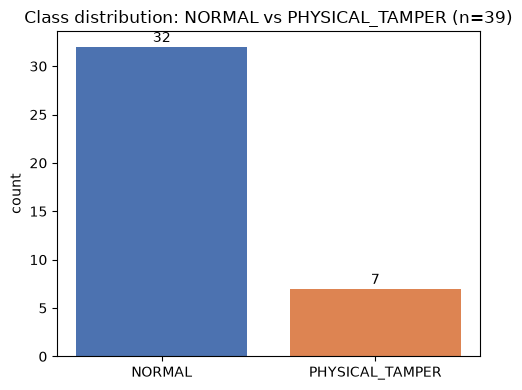

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = y.value_counts().reindex(LABEL_ORDER)
ax.bar(LABEL_ORDER, counts.values, color=[COLORS[c] for c in LABEL_ORDER])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
ax.set_ylabel("count")
ax.set_title(f"Class distribution: NORMAL vs PHYSICAL_TAMPER (n={len(y)})")
plt.tight_layout()
plt.show()

### 9.2 Feature distributions

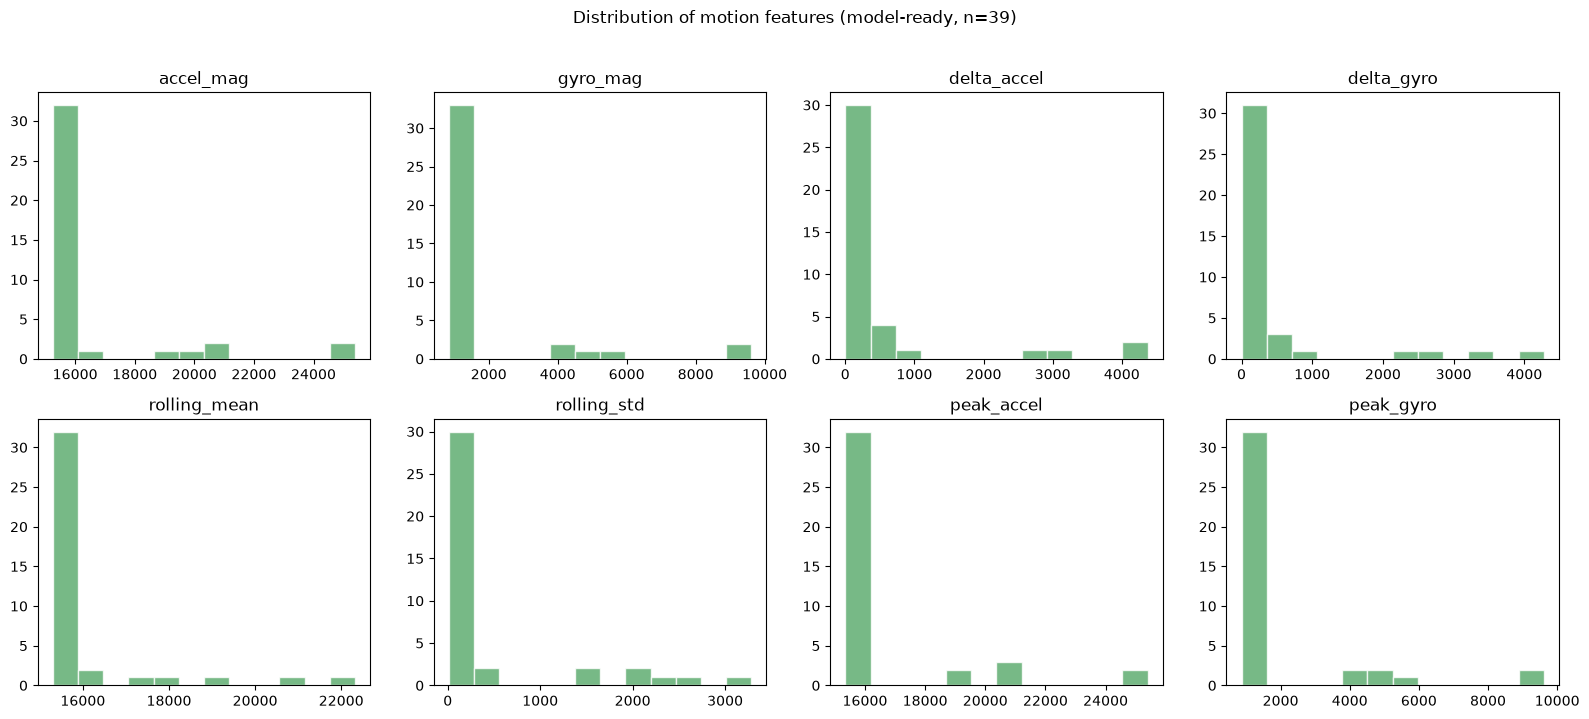

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feature in zip(axes.flat, MOTION_FEATURES):
    ax.hist(X[feature], bins=12, color="#55A868", alpha=0.8, edgecolor="white")
    ax.set_title(feature)
fig.suptitle("Distribution of motion features (model-ready, n=39)", y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Class-wise boxplots

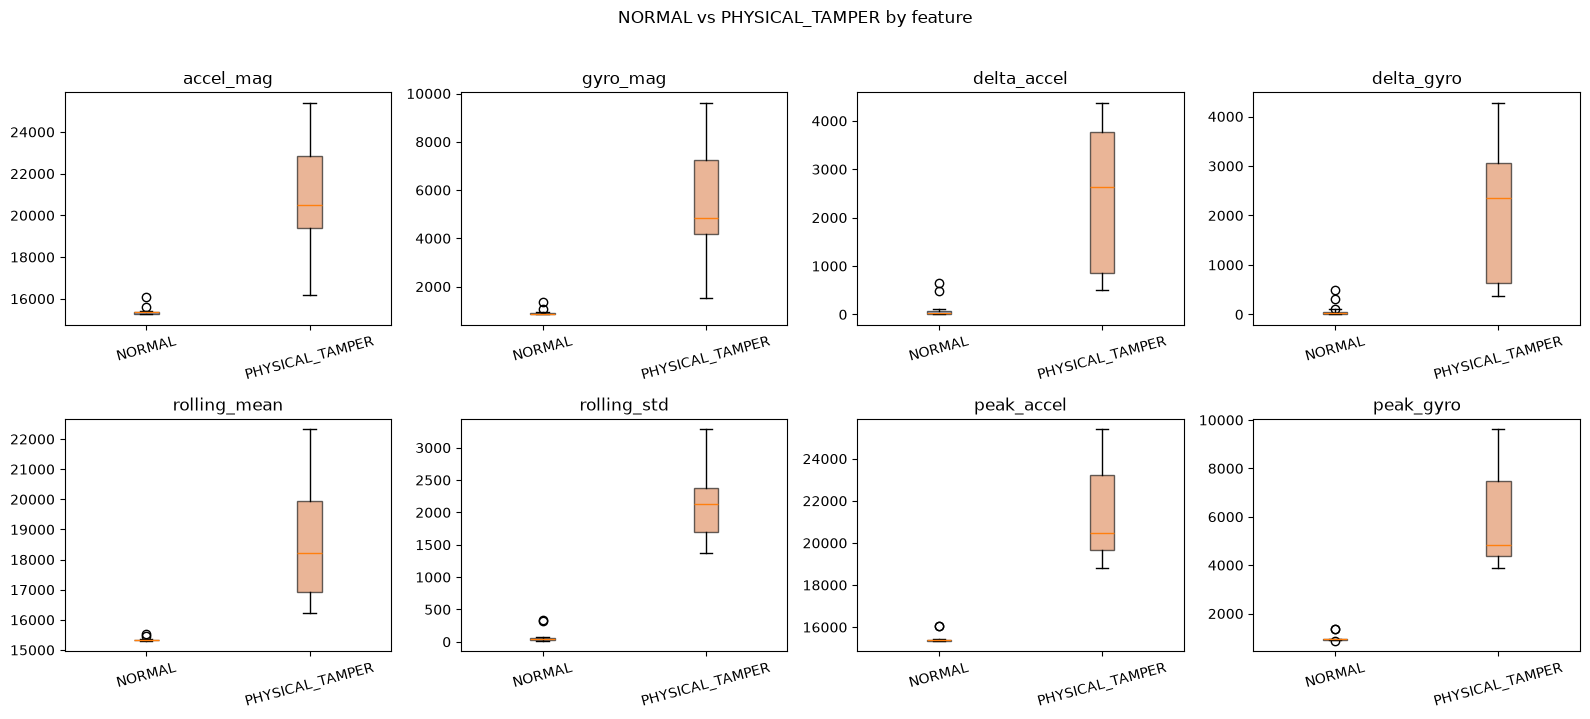

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feature in zip(axes.flat, MOTION_FEATURES):
    data_by_class = [X[y == cls][feature].values for cls in LABEL_ORDER]
    bp = ax.boxplot(data_by_class, tick_labels=LABEL_ORDER, patch_artist=True)
    for patch, cls in zip(bp["boxes"], LABEL_ORDER):
        patch.set_facecolor(COLORS[cls])
        patch.set_alpha(0.6)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("NORMAL vs PHYSICAL_TAMPER by feature", y=1.02)
plt.tight_layout()
plt.show()

### 9.4 Correlation heatmap

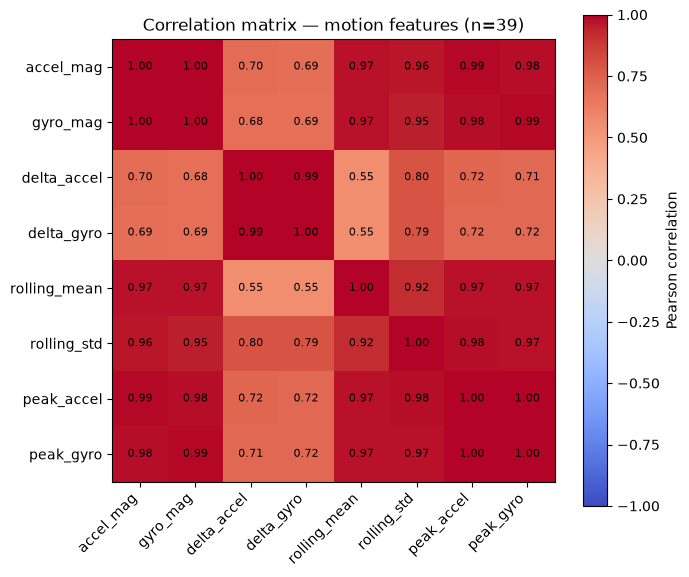

,accel_mag,gyro_mag,delta_accel,delta_gyro,rolling_mean,rolling_std,peak_accel,peak_gyro
accel_mag,1.00,1.00,0.70,0.69,0.97,0.96,0.99,0.98
gyro_mag,1.00,1.00,0.68,0.69,0.97,0.95,0.98,0.99
delta_accel,0.70,0.68,1.00,0.99,0.55,0.80,0.72,0.71
delta_gyro,0.69,0.69,0.99,1.00,0.55,0.79,0.72,0.72
rolling_mean,0.97,0.97,0.55,0.55,1.00,0.92,0.97,0.97
rolling_std,0.96,0.95,0.80,0.79,0.92,1.00,0.98,0.97
peak_accel,0.99,0.98,0.72,0.72,0.97,0.98,1.00,1.00
peak_gyro,0.98,0.99,0.71,0.72,0.97,0.97,1.00,1.00


In [13]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(MOTION_FEATURES))); ax.set_yticks(range(len(MOTION_FEATURES)))
ax.set_xticklabels(MOTION_FEATURES, rotation=45, ha="right")
ax.set_yticklabels(MOTION_FEATURES)
for i in range(len(MOTION_FEATURES)):
    for j in range(len(MOTION_FEATURES)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title(f"Correlation matrix — motion features (n={len(X)})")
plt.tight_layout()
plt.show()
corr.round(2)

### 9.5 Class-wise descriptive statistics

In [14]:
desc = df_model_ready.groupby(TARGET_COLUMN)[MOTION_FEATURES].agg(["mean", "std", "min", "max"]).round(2)
desc.reindex(LABEL_ORDER).T

physical_target      NORMAL  PHYSICAL_TAMPER
accel_mag    mean  15363.61         20941.17
             std     142.81          3226.28
             min   15250.47         16178.07
             max   16064.85         25393.70
gyro_mag     mean    912.70          5554.11
             std      94.91          2897.42
             min     849.66          1535.84
             max    1382.39          9611.58
delta_accel  mean     74.18          2397.03
             std     133.71          1665.51
             min       0.90           514.24
             max     641.90          4371.57
delta_gyro   mean     55.54          2059.32
             std     100.49          1533.66
             min       0.77           368.00
             max     501.07          4274.68
rolling_mean mean  15340.28         18644.99
             std      46.32          2244.89
             min   15302.49         16242.56
             max   15535.28         22320.05
rolling_std  mean     59.58          2133.16
             std      71.60           652.58
             min      14.30          1377.53
             max     335.92          3282.95
peak_accel   mean  15414.20         21487.24
             std     171.99          2800.60
             min   15346.30         18809.84
             max   16064.85         25393.70
peak_gyro    mean    956.44          6002.87
             std     114.09          2520.22
             min     871.28          3893.44
             max    1382.39          9611.58

In [15]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X, y)
print("Decision Tree fit on all 39 model-ready rows (prototype demonstration).")

Decision Tree fit on all 39 model-ready rows (prototype demonstration).


## 11. Learned tree rules

In [16]:
rules = export_text(tree_model, feature_names=MOTION_FEATURES)
print(rules)

|--- accel_mag <= 16121.46
|   |--- class: NORMAL
|--- accel_mag >  16121.46
|   |--- class: PHYSICAL_TAMPER



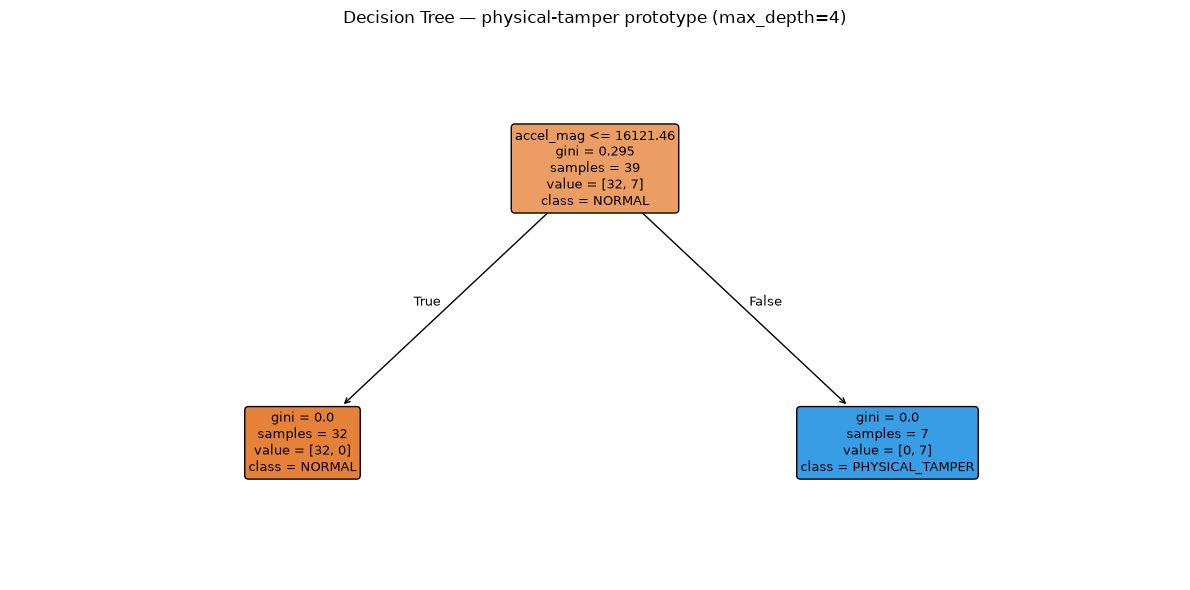

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(tree_model, feature_names=MOTION_FEATURES, class_names=tree_model.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree — physical-tamper prototype (max_depth=4)")
plt.tight_layout()
plt.show()

In [18]:
importances = pd.Series(tree_model.feature_importances_, index=MOTION_FEATURES).sort_values(ascending=False)
importances

accel_mag       1.0
gyro_mag        0.0
delta_accel     0.0
delta_gyro      0.0
rolling_mean    0.0
rolling_std     0.0
peak_accel      0.0
peak_gyro       0.0
dtype: float64

## 13. Training confusion matrix & report — TRAINING ONLY

Fit to the training rows themselves; not test/validation metrics.

In [19]:
y_pred_train = tree_model.predict(X)

cm = confusion_matrix(y, y_pred_train, labels=LABEL_ORDER)
cm_df = pd.DataFrame(cm, index=[f"actual_{c}" for c in LABEL_ORDER],
                      columns=[f"pred_{c}" for c in LABEL_ORDER])
print("TRAINING confusion matrix (NOT a test-set result):")
print(cm_df)
print()
print("TRAINING classification report (NOT a test-set result):")
print(classification_report(y, y_pred_train, labels=LABEL_ORDER))

TRAINING confusion matrix (NOT a test-set result):
                        pred_NORMAL  pred_PHYSICAL_TAMPER
actual_NORMAL                    32                     0
actual_PHYSICAL_TAMPER            0                     7

TRAINING classification report (NOT a test-set result):
                 precision    recall  f1-score   support

         NORMAL       1.00      1.00      1.00        32
PHYSICAL_TAMPER       1.00      1.00      1.00         7

       accuracy                           1.00        39
      macro avg       1.00      1.00      1.00        39
   weighted avg       1.00      1.00      1.00        39



In [20]:
# Contextual reference only — NOT a model-performance claim.
majority_pred = pd.Series(["NORMAL"] * len(y), index=y.index)
baseline_acc = accuracy_score(y, majority_pred)
print(f"Trivial majority-class baseline (always predict NORMAL): {baseline_acc:.4f} "
      f"({(y == 'NORMAL').sum()}/{len(y)})")
print("This baseline catches 0 of 7 PHYSICAL_TAMPER cases (recall=0.0) yet still scores")
print("high on accuracy — illustrating why accuracy alone is misleading on this imbalance.")

Trivial majority-class baseline (always predict NORMAL): 0.8205 (32/39)
This baseline catches 0 of 7 PHYSICAL_TAMPER cases (recall=0.0) yet still scores
high on accuracy — illustrating why accuracy alone is misleading on this imbalance.


In [21]:
session_class = pd.crosstab(df_model_ready["session_id"], df_model_ready[TARGET_COLUMN])
session_class

physical_target,NORMAL,PHYSICAL_TAMPER
session_id,,
EXP_01_NORMAL_STATIONARY_S1,5,0
EXP_01_NORMAL_STATIONARY_S2,21,0
EXP_02_PHYSICAL_EXPERIMENTS_LABELED_S1,6,7
